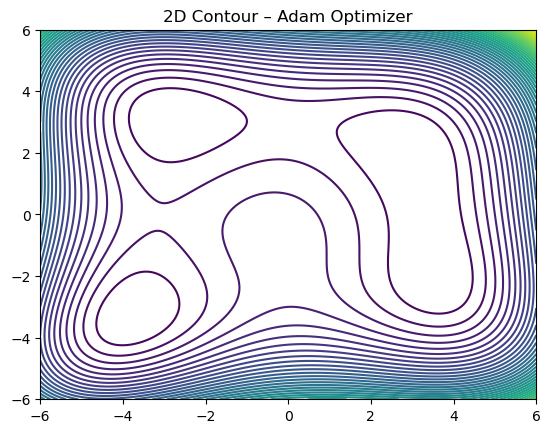

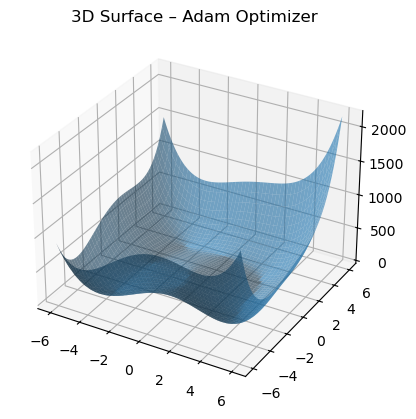

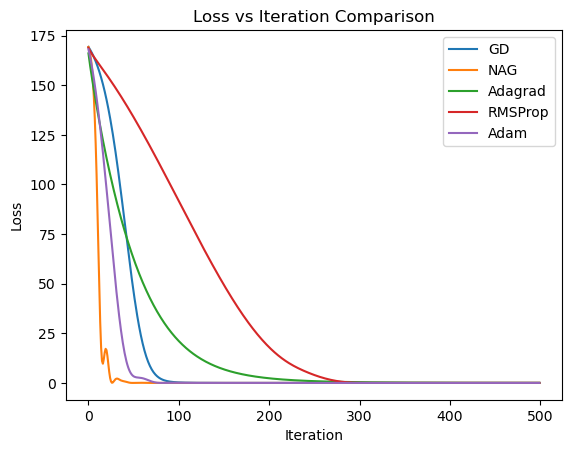

In [2]:
# ===============================
# PART 1 – OPTIMIZER VISUALIZATION
# ===============================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D

# --------------------------------
# 1. Define Himmelblau Function
# --------------------------------
def loss(w):
    w1, w2 = w
    return (w1**2 + w2 - 11)**2 + (w1 + w2**2 - 7)**2

def gradient(w):
    w1, w2 = w
    dJ_dw1 = 4*w1*(w1**2 + w2 - 11) + 2*(w1 + w2**2 - 7)
    dJ_dw2 = 2*(w1**2 + w2 - 11) + 4*w2*(w1 + w2**2 - 7)
    return np.array([dJ_dw1, dJ_dw2])

# --------------------------------
# 2. Optimizers
# --------------------------------

def gradient_descent(w, lr=0.001, iters=500):
    history = []
    for i in range(iters):
        w = w - lr * gradient(w)
        history.append(w.copy())
    return np.array(history)

def momentum_gd(w, lr=0.001, beta=0.9, iters=500):
    v = np.zeros_like(w)
    history = []
    for i in range(iters):
        v = beta*v + lr*gradient(w)
        w = w - v
        history.append(w.copy())
    return np.array(history)

def nesterov(w, lr=0.001, beta=0.9, iters=500):
    v = np.zeros_like(w)
    history = []
    for i in range(iters):
        lookahead = w - beta*v
        v = beta*v + lr*gradient(lookahead)
        w = w - v
        history.append(w.copy())
    return np.array(history)

def adagrad(w, lr=0.1, iters=500):
    eps = 1e-8
    G = np.zeros_like(w)
    history = []
    for i in range(iters):
        g = gradient(w)
        G += g**2
        w = w - (lr / (np.sqrt(G)+eps)) * g
        history.append(w.copy())
    return np.array(history)

def rmsprop(w, lr=0.01, beta=0.9, iters=500):
    eps = 1e-8
    Eg = np.zeros_like(w)
    history = []
    for i in range(iters):
        g = gradient(w)
        Eg = beta*Eg + (1-beta)*(g**2)
        w = w - (lr/(np.sqrt(Eg)+eps))*g
        history.append(w.copy())
    return np.array(history)

def adam(w, lr=0.05, iters=500):
    beta1, beta2 = 0.9, 0.999
    eps = 1e-8
    m = np.zeros_like(w)
    v = np.zeros_like(w)
    history = []
    for t in range(1, iters+1):
        g = gradient(w)
        m = beta1*m + (1-beta1)*g
        v = beta2*v + (1-beta2)*(g**2)
        m_hat = m/(1-beta1**t)
        v_hat = v/(1-beta2**t)
        w = w - lr*m_hat/(np.sqrt(v_hat)+eps)
        history.append(w.copy())
    return np.array(history)

# --------------------------------
# 3. Run Optimizers
# --------------------------------

initial_w = np.array([0.0, 0.0])

gd_path = gradient_descent(initial_w.copy())
nag_path = nesterov(initial_w.copy())
ada_path = adagrad(initial_w.copy())
rms_path = rmsprop(initial_w.copy())
adam_path = adam(initial_w.copy())

# --------------------------------
# 4. 2D Contour Animation
# --------------------------------

w1 = np.linspace(-6,6,400)
w2 = np.linspace(-6,6,400)
W1, W2 = np.meshgrid(w1,w2)
Z = (W1**2 + W2 - 11)**2 + (W1 + W2**2 - 7)**2

fig, ax = plt.subplots()
ax.contour(W1,W2,Z,levels=50)

line, = ax.plot([],[],'r-o')

def update(frame):
    line.set_data(adam_path[:frame,0], adam_path[:frame,1])
    return line,

ani = FuncAnimation(fig, update, frames=len(adam_path), interval=30)
plt.title("2D Contour – Adam Optimizer")
plt.show()

# --------------------------------
# 5. 3D Surface Animation
# --------------------------------

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W1,W2,Z,alpha=0.6)

line3d, = ax.plot([],[],[],'r-o')

def update3d(frame):
    x = adam_path[:frame,0]
    y = adam_path[:frame,1]
    z = [loss([x[i],y[i]]) for i in range(len(x))]
    line3d.set_data(x,y)
    line3d.set_3d_properties(z)
    return line3d,

ani = FuncAnimation(fig, update3d, frames=len(adam_path), interval=30)
plt.title("3D Surface – Adam Optimizer")
plt.show()

# --------------------------------
# 6. Loss vs Iteration Comparison
# --------------------------------

plt.plot([loss(w) for w in gd_path], label="GD")
plt.plot([loss(w) for w in nag_path], label="NAG")
plt.plot([loss(w) for w in ada_path], label="Adagrad")
plt.plot([loss(w) for w in rms_path], label="RMSProp")
plt.plot([loss(w) for w in adam_path], label="Adam")

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss vs Iteration Comparison")
plt.show()

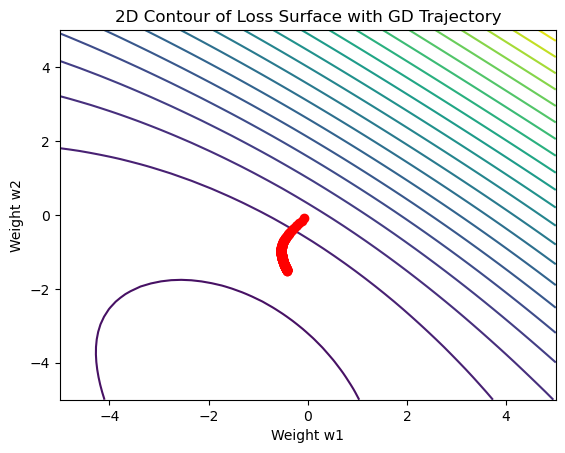

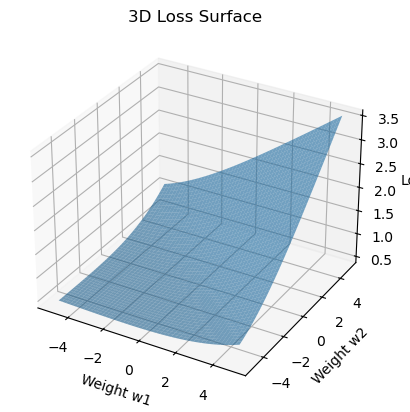

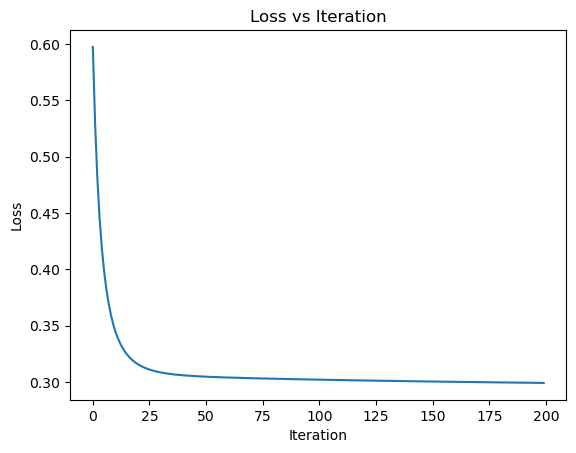

In [13]:
# ==================================
# PART 2 – MNIST (Using 2 Meaningful Features)
# ==================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --------------------------------
# 1. Load MNIST Dataset
# --------------------------------
df = pd.read_csv(r"C:\Users\Janani\Downloads\mnist_train.csv")

df = df.head(500)

# Binary classification: Digit 0 vs Not 0
y = (df.iloc[:,0] == 0).astype(int).values.reshape(-1,1)

# ✅ Use meaningful pixels instead of first 2
X = df.iloc[:,350:352].values

# Normalize
X = X / 255.0

# Add bias
X = np.hstack((np.ones((X.shape[0],1)), X))

# --------------------------------
# 2. Logistic Regression
# --------------------------------
def sigmoid(z):
    return 1/(1+np.exp(-z))

def loss(w):
    h = sigmoid(X @ w)
    return -np.mean(y*np.log(h+1e-8) + (1-y)*np.log(1-h+1e-8))

def gradient(w):
    h = sigmoid(X @ w)
    return (1/len(y))*(X.T @ (h-y))

# --------------------------------
# 3. Gradient Descent
# --------------------------------
def gradient_descent(w, lr=0.5, iters=200):
    losses = []
    path = []

    for i in range(iters):
        w = w - lr*gradient(w)
        path.append(w.copy())
        losses.append(loss(w))

    return w, losses, np.array(path)

w_init = np.zeros((X.shape[1],1))
w_final, losses, path = gradient_descent(w_init)

# --------------------------------
# Create Loss Surface
# --------------------------------
w1 = np.linspace(-5,5,50)
w2 = np.linspace(-5,5,50)
W1, W2 = np.meshgrid(w1,w2)
Z = np.zeros(W1.shape)

for i in range(len(w1)):
    for j in range(len(w2)):
        temp_w = np.array([[0],[W1[i,j]],[W2[i,j]]])
        Z[i,j] = loss(temp_w)

# --------------------------------
# GRAPH 1 – 2D Contour + GD Path
# --------------------------------
plt.figure()
plt.contour(W1, W2, Z, levels=30)
plt.plot(path[:,1], path[:,2], 'r-o')
plt.xlabel("Weight w1")
plt.ylabel("Weight w2")
plt.title("2D Contour of Loss Surface with GD Trajectory")
plt.show()

# --------------------------------
# GRAPH 2 – 3D Loss Surface (No Red Path)
# --------------------------------
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W1, W2, Z, alpha=0.6)
ax.set_xlabel("Weight w1")
ax.set_ylabel("Weight w2")
ax.set_zlabel("Loss")
ax.set_title("3D Loss Surface")
plt.show()

# --------------------------------
# GRAPH 3 – Loss vs Iteration
# --------------------------------
plt.figure()
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss vs Iteration")
plt.show()